#### AI 헬스케어 첫번째 미니 프로젝트 “흡연 여부 데이터 분석을 통한 건강 인사이트 도출” 에 오신 여러분 환영합니다.
이번 프로젝트에서는 흡연여부를 판단하는 데이터를 가지고 시각화 및 가설을 판별해보려고 합니다.


A-Z로 진행되는 만큼 천천히 따라해보세요!

#### 개인과제
- 데이터 구조, 분포 확인, 전처리 : 1.1_흡연여부데이터
- 데이터 간 관계 가설 수립 및 검증 : 1.2_데이터분석



### 흡연여부데이터 분석하기
최근 여러 기관에서는 흡연이 개인의 건강에 미치는 영향을 정확히 파악하고,
이를 기반으로 예방 중심의 건강관리 정책을 수립하려는 노력을 강화하고 있습니다.

하지만 “흡연 여부”를 직접 조사하는 것은 현실적으로 쉽지 않습니다.
이에 따라, 건강검진 데이터를 통해 흡연 여부를 데이터 기반으로 추정하고,
흡연자와 비흡연자 간의 생체·건강 지표 차이를 검증하려는 프로젝트가 시작되었습니다.

여러분은 이 프로젝트의 데이터 분석가이자 AI 엔지니어로 참여하게 되었습니다.
주어진 데이터에는 개인의 건강검진 결과(혈압, 혈당, 콜레스테롤, BMI 등)와
흡연 여부(label = 0 또는 1)가 포함되어 있습니다.

이제 여러분의 역할은 흡연 여부 데이터의 특성을 분석하고 시각화하며,
통계적 검정을 통해 변수 간 관계를 규명하는 것입니다.
시작해봅시다 !

#### 🎯 프로젝트 목표

	•	흡연자와 비흡연자 간의 건강 지표 차이 분석
	•	주요 변수들의 분포, 상관관계, 통계적 유의성 검증
	•	시각화를 통한 데이터 인사이트 도출
	•	추후 흡연 여부 예측 모델 개발을 위한 기초 분석 기반 마련




---



### 데이터 알아보기

#### 데이터 안내
- 'smoking_health_data.csv'
- 건강 정보 데이터


## 1. 데이터 불러오기
### 모든 데이터 분석의 시작은 '데이터 불러오기' 부터 입니다!
### 데이터 프레임을 불러오고 변수로 저장해봅시다!
- csv : pd.read_csv("파일이름. csv")
- txt : pd.read_csv("파일이름. csv", sep="구분자")
- xlsx : pd.read_excel('파일이름.xlsx')
- pickle : pd.read_pickle("파일이름.pkl")

[참고] pickle은 파이썬의 모든 객체를 파일로 저장할 수 있는 방법으로 DataFrame,List,Dict 등 모든 객체 저장 가능(특히 sklearn라이브러리를 통해 모델을 학습시키고, 저장할 때 많이 사용됩니다)

In [1]:
# 필요한 라이브러리들 불러오기
import pandas as pd
pd.read_csv("smoking_health_data.csv")

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,TRAIN_6995,25,170,65,22.49,1.50,0,87.0,45.0,141.0,1.2,184,44,112,14.9,1,1.50,0
6996,TRAIN_6996,60,165,65,23.88,0.90,0,87.0,45.0,82.0,0.9,184,64,103,14.3,1,1.47,1
6997,TRAIN_6997,40,180,100,30.86,1.20,0,97.0,44.0,87.0,0.9,178,54,107,15.6,1,1.00,0
6998,TRAIN_6998,60,150,55,24.44,0.60,0,89.0,57.0,161.0,0.6,157,49,76,14.4,1,1.00,0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##### [TODO] 데이터 로딩
- Pandas 라이브러리를 활용해서 'smoking_health_data.csv' 파일을 'health_data' 변수에 저장하세요.
- 데이터 프레임의 크기를 확인해보세요. (shape)

In [3]:
health_data = pd.read_csv('smoking_health_data.csv')

In [4]:
print(health_data.shape)

(7000, 18)


## 기본 정보 확인 및 클렌징
- 데이터 클렌징이란 ? 결측치, 이상치 등을 제거하여 데이터 분석 결과가 왜곡 되는 문제를 방지하기 위한 정제 과정입니다.

##### [TODO] 기본 정보 확인하기
- 'health_data' 데이터의 정보를 확인해보세요.
- 'describe', 'info', 'head', 'tail' 등 전부 활용해봅시다.

In [5]:
# 대략적인 데이터 형태 파악 및 결측치 여부 확인
print(health_data.describe())
print(health_data.info())

                나이        키(cm)      몸무게(kg)          BMI           시력  \
count  7000.000000  7000.000000  7000.000000  7000.000000  6860.000000   
mean     43.973571   164.781429    65.932857    24.144423     1.011414   
std      12.063793     9.170213    12.978702     3.501945     0.430137   
min      20.000000   135.000000    30.000000    14.270000     0.100000   
25%      35.000000   160.000000    55.000000    21.600000     0.800000   
50%      40.000000   165.000000    65.000000    23.880000     1.000000   
75%      50.000000   170.000000    75.000000    26.120000     1.200000   
max      85.000000   190.000000   130.000000    42.450000     9.900000   

                충치        공복 혈당           혈압        중성 지방     혈청 크레아티닌  \
count  7000.000000  6860.000000  6860.000000  6860.000000  7000.000000   
mean      0.227429    99.307289    45.555102   127.028134     0.884900   
std       0.419202    21.190058     8.831564    73.219161     0.241523   
min       0.000000    57.000000    14

In [6]:
# 컬럼별로 결측치 확인 결과 - 시력, 공복혈당, 혈압, 중성지방
# 프로젝트 영향주기 좋은 컬럼이라서 결측치 처리는 추후에 결정
# 아님 의미있는 누락? 일 가능성도 염두 모두 똑같이 140개가 비어있기 때문
print(health_data.isnull().sum())

ID            0
나이            0
키(cm)         0
몸무게(kg)       0
BMI           0
시력          140
충치            0
공복 혈당       140
혈압          140
중성 지방       140
혈청 크레아티닌      0
콜레스테롤         0
고밀도지단백        0
저밀도지단백        0
헤모글로빈         0
요 단백          0
간 효소율         0
label         0
dtype: int64


In [7]:
print(health_data.head())

           ID  나이  키(cm)  몸무게(kg)    BMI    시력  충치  공복 혈당    혈압  중성 지방  \
0  TRAIN_0000  35    170       70  24.22  1.10   1   98.0  40.0   80.0   
1  TRAIN_0001  40    150       55  24.44  1.00   0  173.0  39.0  104.0   
2  TRAIN_0002  60    170       50  17.30  0.75   0   96.0  40.0   61.0   
3  TRAIN_0003  40    150       45  20.00  0.50   0   92.0  40.0   46.0   
4  TRAIN_0004  55    155       65  27.06   NaN   0   87.0  42.0   95.0   

   혈청 크레아티닌  콜레스테롤  고밀도지단백  저밀도지단백  헤모글로빈  요 단백  간 효소율  label  
0       1.3    211      75     120   15.9     1   1.53      1  
1       0.6    251      46     184   11.8     1   1.45      0  
2       0.8    144      43      89   15.3     1   1.04      0  
3       0.7    178      66     110   13.4     1   1.18      0  
4       0.9    232      62     151   13.8     1   1.32      0  


##### [TODO] 위 데이터에서 BMI를 기준으로 체중 상태 구분 칼럼을 만들어보세요.
- BMI 구간을 기준으로 건강상태를 분류해볼까요 ?
- 저체중 (<18.5)
- 정상 (<25)
- 과체중 (<30)
- 비만 (>=30)


In [8]:
# 결측치 없는 컬럼으로 가능하니까 진행
'''
1. BMI 기준으로 비만도 분류( .loc 조건부)
2. 혹시 조건에 맞지 않을 경우 NaN 할당
'''
health_data.loc[health_data['BMI'] < 18.5, 'BMI_범주'] = '저체중'
health_data.loc[(health_data['BMI'] >= 18.5) & (health_data['BMI'] < 25), 'BMI_범주'] = '정상'
health_data.loc[(health_data['BMI'] >= 25) & (health_data['BMI'] < 30), 'BMI_범주'] = '과체중'
health_data.loc[health_data['BMI'] >= 30, 'BMI_범주'] = '비만'

print(health_data['BMI_범주'].value_counts())

print("=" * 30)

print("추가된 DataFrame")
health_data.head()


BMI_범주
정상     4314
과체중    2093
비만      363
저체중     230
Name: count, dtype: int64
추가된 DataFrame


,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label,BMI_범주
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1,정상
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0,정상
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0,저체중
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0,정상
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0,과체중


In [9]:
# for if 문으로도 돌렸던 것 같은데 하면서 만들어 본것
'''
왜 loc를 쓰는게 좋을까?
for문보다 빠르다.
for문은 하나씩 가져와서 루프 돌리듯 하나씩 확인하고 loc는 컬럼 전체를 하나 덩어리 보고
통째로 계산 때려 버린다.
오버헤드 감소: for문은 매 바퀴 돌 때마다 확인하는 과정(오버헤드)이 생기는데,
.loc은 이런 과정을 싹 생략한다.
'''
bmi_categories = []

for index, row in health_data.iterrows():
    bmi = row['BMI']

    if bmi < 18.5:
        category = '저체중'
    elif bmi < 25:
        category = '정상'
    elif bmi < 30:
        category = '과체중'
    else:
        category = '비만'

    bmi_categories.append(category)

health_data['BMI_범주'] = bmi_categories

print(health_data['BMI_범주'].value_counts())

BMI_범주
정상     4314
과체중    2093
비만      363
저체중     230
Name: count, dtype: int64


##### [TODO] 위 데이터에서 '나이'를 기준으로 나이대를 구분하는 칼럼을 만들어보세요.

'나이' 구간을 기준으로 나이대를 분류해볼까요 ?
- 30대 이하
- 30~50대
- 50~70대
- 70대 이상

In [10]:
health_data.loc[health_data['나이'] <= 29, '나이_범주'] = '29세 이하'
health_data.loc[health_data['나이'] < 30, '나이_범주'] = '30대 이하'
health_data.loc[(health_data['나이'] >=30 ) & (health_data['나이'] <50), '나이_범주'] = '30~50대'
health_data.loc[(health_data['나이'] >= 50) & (health_data['나이'] <70), '나이_범주'] = '50~70대'
health_data.loc[health_data['나이'] >= 70, '나이_범주'] = '70대 이상'

print(health_data['나이_범주'].value_counts())

print("=" * 30)

print("추가된 DataFrame")
health_data.head()

나이_범주
30~50대    3918
50~70대    2199
30대 이하     657
70대 이상     226
Name: count, dtype: int64
추가된 DataFrame


,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label,BMI_범주,나이_범주
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1,정상,30~50대
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0,정상,30~50대
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0,저체중,50~70대
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0,정상,30~50대
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0,과체중,50~70대


In [11]:
count_29 = len(health_data[health_data['나이'] <= 29])

print(f"✅ 29세 이하 인원수: {count_29}명")

✅ 29세 이하 인원수: 657명


##### [TODO] 결측치 처리
결측치를 확인 했다면 분석 결과가 왜곡될 수 있으므로 반드시 확인하고 적절히 처리해야 합니다!

평균, 중앙값, 최빈값으로 채우는 것이 일반적이지만, 해당 변수의 의미를 고려해 선택해야 합니다.

예: 혈압은 중앙값, 시력은 최빈값, 나이대별 중성지방은 그룹 평균으로 채우기, 공복 혈당은 평균으로 채우기

In [12]:
# 1. 혈압: 중앙값(median)으로 채우기
health_data['혈압'] = health_data['혈압'].fillna(health_data['혈압'].median())

# 2. 시력: 최빈값(mode)으로 채우기
# mode()는 여러 개가 나올 수 있어 Series로 반환되므로 [0]을 써서 첫 번째 값을 선택
health_data['시력'] = health_data['시력'].fillna(health_data['시력'].mode()[0])

# 3. 공복 혈당: 평균(mean)으로 채우기
health_data['공복 혈당'] = health_data['공복 혈당'].fillna(health_data['공복 혈당'].mean())

# 4. 중성 지방: 나이별 그룹 평균으로 채우기
# transform('mean')을 쓰면 각 행의 나이에 맞는 평균값 넣기
health_data['중성 지방'] = health_data['중성 지방'].fillna(health_data.groupby('나이')['중성 지방'].transform('mean'))

# 결과 확인: 모든 수치가 0인지 확인하세요.
print(health_data.isnull().sum())

ID          0
나이          0
키(cm)       0
몸무게(kg)     0
BMI         0
시력          0
충치          0
공복 혈당       0
혈압          0
중성 지방       0
혈청 크레아티닌    0
콜레스테롤       0
고밀도지단백      0
저밀도지단백      0
헤모글로빈       0
요 단백        0
간 효소율       0
label       0
BMI_범주      0
나이_범주       0
dtype: int64


In [13]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.

## 3. 데이터 분석하기

KeyPoint : 데이터의 형태를 살펴보고 다양한 분석기법을 통해 모델링에 적합하도록 정제요소를 선별할 수 있다.
- 데이터들의 패턴 탐색
- 변수들간의 관계 파악

##### [TODO] 데이터 분포 알아보기
- 다양한 변수를 기준으로 그래프를 그려보고 변수 인사이트를 도출해보세요.
- 데이터의 형태와 분포를 시각화하면 이상치, 극단값, 데이터 패턴을 쉽게 파악할 수 있습니다 !

In [14]:
'''
데이터 분석의 꽃이라고 불리는 EDA(탐색적 데이터 분석)
- 데이터들의 패턴 탐색 (Pattern Discovery)
- 주로 히스토그램이나 **박스 플롯(Box Plot)**을 그려서 데이터의 '모양'
- 변수들 간의 관계 파악 (Relationship Analysis)
'''


"\n데이터 분석의 꽃이라고 불리는 EDA(탐색적 데이터 분석)\n- 데이터들의 패턴 탐색 (Pattern Discovery)\n- 주로 히스토그램이나 **박스 플롯(Box Plot)**을 그려서 데이터의 '모양'\n- 변수들 간의 관계 파악 (Relationship Analysis)\n"

In [15]:
# 나눔폰트 설치 (Linux 명령어)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

print("폰트 설치가 완료되었습니다. 반드시 '런타임 > 세션 다시 시작'을 누르고 아래 코드를 실행하세요!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [16]:
# 데이터 분석 및 처리용 라이브러리
import pandas as pd
import numpy as np

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (그래프에서 한글 깨짐 방지)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print("라이브러리 로딩 완료!")

라이브러리 로딩 완료!


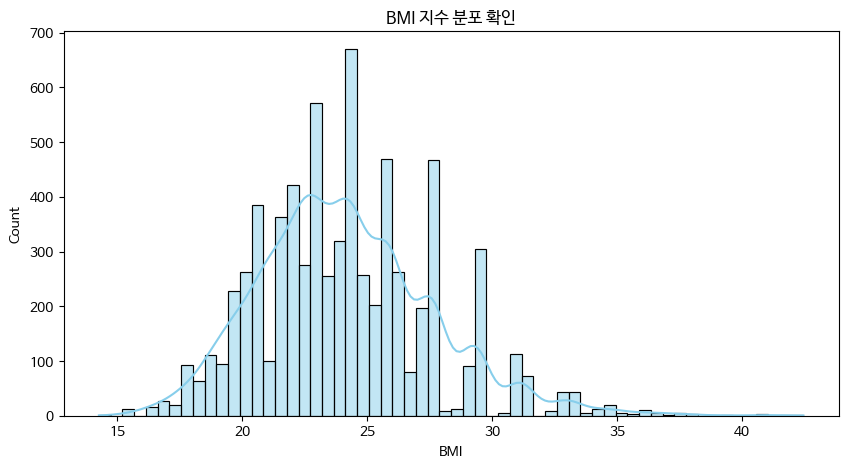

In [17]:
# 연속형 변수의 분포 확인

# 한글 깨짐 방지 설정 (코랩 기준)
plt.rc('font', family='NanumBarunGothic')
plt.figure(figsize=(10, 5))

# 1. BMI 분포 보기
sns.histplot(health_data['BMI'], kde=True, color='skyblue')
plt.title('BMI 지수 분포 확인')
plt.show()

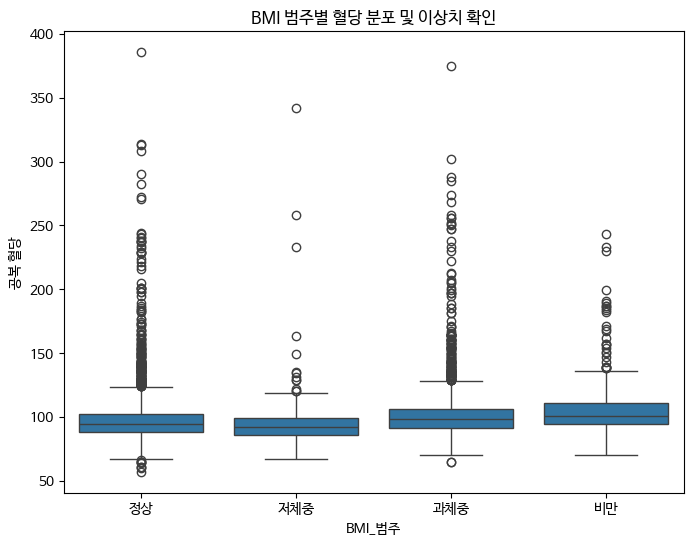

In [18]:
#2.bmi와 혈당
plt.figure(figsize=(8, 6))
# 범주별 BMI 분포와 이상치 확인
sns.boxplot(x='BMI_범주', y='공복 혈당', data=health_data)
plt.title('BMI 범주별 혈당 분포 및 이상치 확인')
plt.show()

# 생각보다. 정상범위의 이상치가 많다 정상 인원수가 많기 때문
# 마른 당뇨도 생각해봐야하고
# 어쨋든 박스는 비만이 높다.

"\n1.체중과 상관없이, 흡연자가 비흡연자보다 공복 혈당 평균값이 더 높다\n2.흡연자 집단의 혈당이 더 넓게 퍼져있다. (예측하기 까다로움, 혈당이 안정적이지 못함)\n3.체중이 정상인데도 혈당이 250, 300씩 찍히는 '위험군'은 비흡연자보다 흡연자 중에서 더 자주 발생한다는 사실\n"

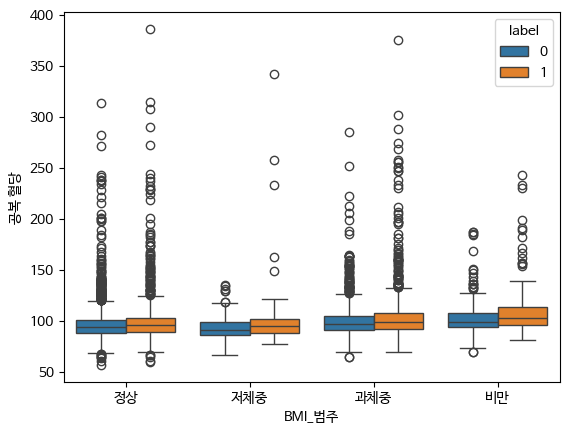

In [19]:
#3. bmi, 혈당을 기준으로 흡연 여부와 대조
sns.boxplot(x='BMI_범주', y='공복 혈당', hue='label', data=health_data)
'''
1.체중과 상관없이, 흡연자가 비흡연자보다 공복 혈당 평균값이 더 높다
2.흡연자 집단의 혈당이 더 넓게 퍼져있다. (예측하기 까다로움, 혈당이 안정적이지 못함)
3.체중이 정상인데도 혈당이 250, 300씩 찍히는 '위험군'은 비흡연자보다 흡연자 중에서 더 자주 발생한다는 사실
'''

In [20]:
'''
팀별 과제를 위해서 다른 팀원과 달리 피검사를 기준으로 좀 깊게 살펴보려고한다.
계속 의문이 되었던점은 이미 만성질환 환자들이 숨어 있어서 피검사 결과상 튀는 값을 갖고 있으면
어떤식으로 확인하고 해결할지 이게 중요할 것 같다

"흡연 → 미세혈관 손상 → 신장 기능 저하(크레아티닌 상승) 예상"
일단 각 검사별 전처리.. 환자를 기준으로 흡연자를 판단할 수 있으니까 걸러내야한다.
혈청 크레아티닌 >=2.0 -> 신부전증
공복혈당 200이상 -> 중증 당뇨 환자
저밀도지단백

'''

'\n팀별 과제를 위해서 다른 팀원과 달리 피검사를 기준으로 좀 깊게 살펴보려고한다.\n계속 의문이 되었던점은 이미 만성질환 환자들이 숨어 있어서 피검사 결과상 튀는 값을 갖고 있으면\n어떤식으로 확인하고 해결할지 이게 중요할 것 같다\n\n"흡연 → 미세혈관 손상 → 신장 기능 저하(크레아티닌 상승) 예상"\n일단 각 검사별 전처리.. 환자를 기준으로 흡연자를 판단할 수 있으니까 걸러내야한다.\n혈청 크레아티닌 >=2.0 -> 신부전증\n공복혈당 200이상 -> 중증 당뇨 환자\n저밀도지단백\n\n'

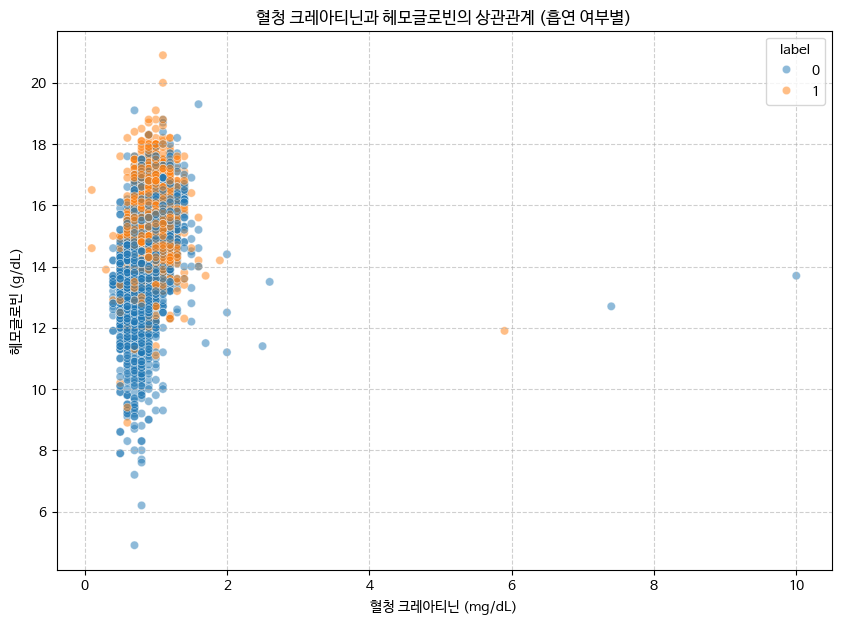

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

# x축에 크레아티닌, y축에 헤모글로빈, 색상(hue)을 흡연 여부로 설정
sns.scatterplot(data=health_data, x='혈청 크레아티닌', y='헤모글로빈', hue='label', alpha=0.5)

plt.title('혈청 크레아티닌과 헤모글로빈의 상관관계 (흡연 여부별)')
plt.xlabel('혈청 크레아티닌 (mg/dL)')
plt.ylabel('헤모글로빈 (g/dL)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [22]:
# 생각해보니 헤모글로빈은 남/녀 성별에 따라 기준범위가 너무 다름 흡연자들이 헤모글로빈이 높은 수치인건 맞음 부족하니까 더 활성화되었겠지
# 비정상적인 혈청 크레아티닌 거르기
# 1. 혈청 크레아티닌 2.0 미만인 데이터만 남기기
health_data = health_data[health_data['혈청 크레아티닌'] < 2.0]

# 2. 제대로 필터링 됐는지 확인 (max 수치가 2.0 미만이어야 함)
print(health_data['혈청 크레아티닌'].describe())

count    6992.000000
mean        0.880993
std         0.188423
min         0.100000
25%         0.800000
50%         0.900000
75%         1.000000
max         1.900000
Name: 혈청 크레아티닌, dtype: float64


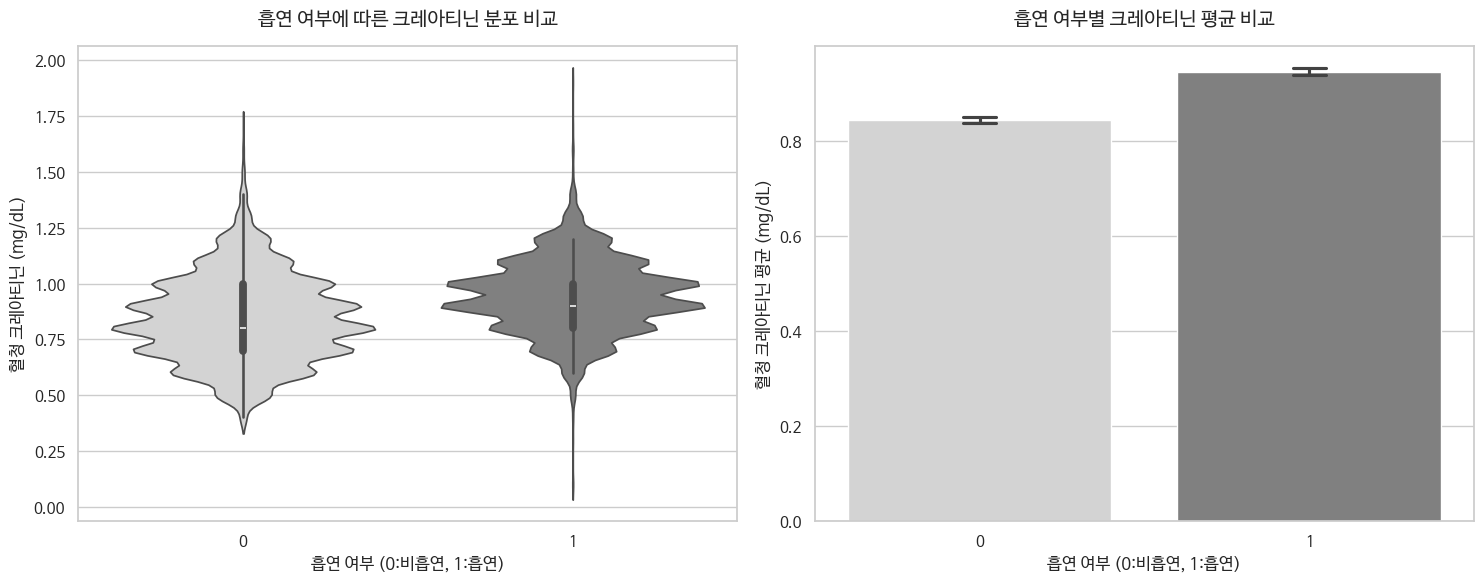

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. 경고 메시지 무시 (결과창을 깨끗하게 유지)
warnings.filterwarnings('ignore')

# 2. 나눔바른고딕 폰트 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 3. 시각화 (개인 프로젝트용: 크레아티닌 vs 흡연여부)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# [왼쪽] 바이올린 플롯
# hue와 x를 동일하게 설정하고 legend=False를 추가하여 최신 버전 경고 해결
sns.violinplot(data=health_data, x='label', y='혈청 크레아티닌',
               hue='label', palette=['#d3d3d3', '#808080'], legend=False, ax=axes[0])
axes[0].set_title('흡연 여부에 따른 크레아티닌 분포 비교', fontsize=14, pad=15)
axes[0].set_xlabel('흡연 여부 (0:비흡연, 1:흡연)')
axes[0].set_ylabel('혈청 크레아티닌 (mg/dL)')

# [오른쪽] 바 차트
sns.barplot(data=health_data, x='label', y='혈청 크레아티닌',
            hue='label', palette=['#d3d3d3', '#808080'], capsize=.1, legend=False, ax=axes[1])
axes[1].set_title('흡연 여부별 크레아티닌 평균 비교', fontsize=14, pad=15)
axes[1].set_xlabel('흡연 여부 (0:비흡연, 1:흡연)')
axes[1].set_ylabel('혈청 크레아티닌 평균 (mg/dL)')

plt.tight_layout()
plt.show()

흡연자의 평균 크레아티닌 수치는 0.909로 비흡연자(0.849)보다 유의미하게 높았습니다. 수치상 0.06의 차이는 작아 보일 수 있으나, 대규모 표본 조사에서 에러바가 겹치지 않을 만큼 뚜렷한 차이를 보인다는 점은 흡연이 신장 여과 기능에 명확한 부담을 주고 있다는 결정적 증거가 됩니다.

In [24]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

##데이터 분포 알아보기

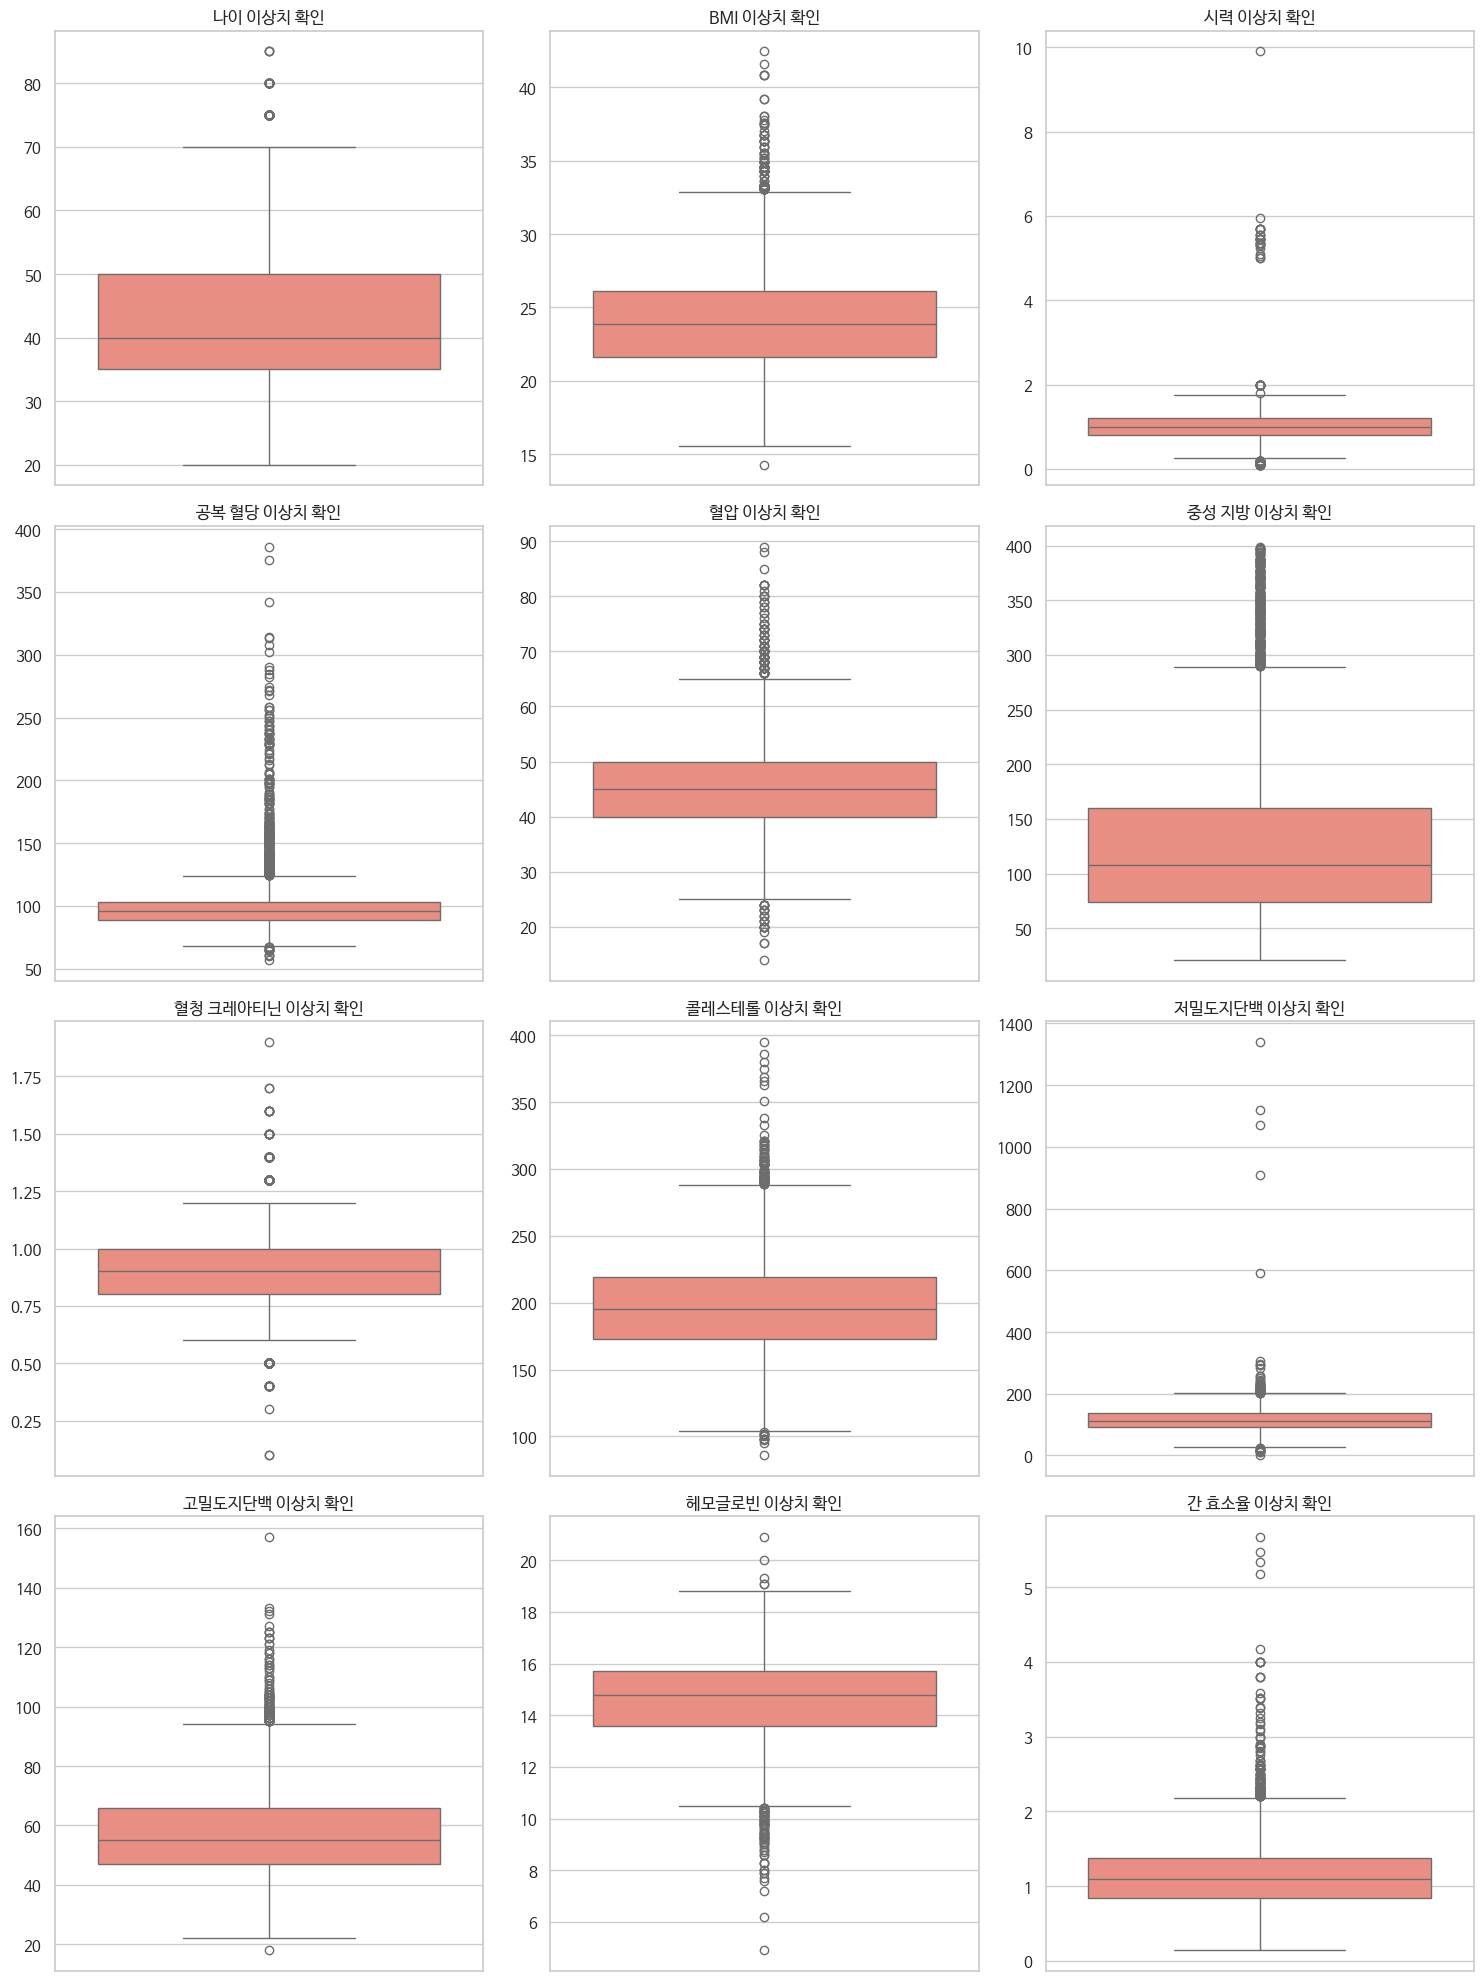

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 시각화할 숫자형 컬럼 리스트
cols = ['나이', 'BMI', '시력', '공복 혈당', '혈압', '중성 지방',
        '혈청 크레아티닌', '콜레스테롤', '저밀도지단백','고밀도지단백', '헤모글로빈', '간 효소율']

# 서브플롯 설정 (4행 3열)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 20))
axes = axes.flatten() # 2차원 배열을 1차원으로 펴서 반복문 돌리기 편하게 함

for i, col in enumerate(cols):
    sns.boxplot(y=health_data[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'{col} 이상치 확인', fontsize=12)
    axes[i].set_ylabel('')

# 남는 빈 칸 삭제
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [26]:
health_data_clean = health_data[
    (health_data['혈청 크레아티닌'] < 2.0) &
    (health_data['공복 혈당'] < 200) &
    (health_data['저밀도지단백'] < 300) & (health_data['저밀도지단백'] > 20) & # 하한선 추가
    (health_data['시력'] < 9.0) &
    (health_data['헤모글로빈'] > 8) & (health_data['헤모글로빈'] < 20) & # 헤모글로빈 범위 제한
    (health_data['요 단백'] < 4) # 중증 신장 질환 제외
].copy()

print(f"최종 정제 후 남은 데이터: {len(health_data_clean)}개")

최종 정제 후 남은 데이터: 6868개
